# 📌 SGD for Linear Regression with Housing Dataset

# ✅ Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

# ✅ Load the Housing Dataset

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/Phionanamugga/teaching/refs/heads/main/datasets/housing.csv")

# ✅ Explore the dataset

In [4]:
print(df.head())
print(df.info())

   id     price  area  bedrooms  bathrooms  stories  stories.1  guestroom  \
0   0  13300000  7420         4          2        3          1          0   
1   1  12250000  8960         4          4        4          1          0   
2   2  12250000  9960         3          2        2          1          0   
3   3  12215000  7500         4          2        2          1          0   
4   4  11410000  7420         4          1        2          1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus  
0               1.0  
1               1.0  
2               0.5  
3               1.0  
4               1.

# ✅ Select Features (X) and Target (y)
# Assuming 'MEDV' (Median Home Value) is the target variable

In [5]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values 

# ✅ Split into Training & Test Sets

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ✅ Normalize Features (SGD is sensitive to scaling)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ✅ Implement SGD for Linear Regression

In [9]:
def sgd_linear_regression(X, y, learning_rate=0.01, epochs=100, batch_size=1):
    m, n = X.shape 
    theta = np.random.randn(n + 1) 
    
 
    X_b = np.c_[np.ones((m, 1)), X]  

    cost_history = []  
    for epoch in range(epochs):
        for i in range(0, m, batch_size):  
            random_index = np.random.randint(m)
            xi = X_b[random_index:random_index+1] 
            yi = y[random_index:random_index+1]

            gradient = 2 * xi.T @ (xi @ theta - yi)  
            theta -= learning_rate * gradient  
            
        cost = mean_squared_error(y, X_b @ theta) 
        cost_history.append(cost)

    return theta, cost_history

# ✅ Run SGD for Linear Regression

In [10]:
theta_sgd, cost_sgd = sgd_linear_regression(X_train_scaled, y_train)

print(f"SGD Model Parameters: {theta_sgd}")

SGD Model Parameters: [ 0.45085147 -0.09310446 -0.02834477 -0.04426551 -0.04349604 -0.06713517
  0.06434977  0.05596622  0.00099797  0.02319029  0.0016388   0.02846
 -0.02549777 -0.01606144]


# ✅ Compare with Scikit-Learn's SGDRegressor

In [11]:
sgd_reg = SGDRegressor(max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X_train_scaled, y_train)

print(f"Sklearn SGDRegressor Coefficients: {sgd_reg.coef_}")

Sklearn SGDRegressor Coefficients: [-0.08040516  0.03228243 -0.02431526 -0.0055606  -0.01502257  0.01838184
  0.02505029  0.00248256  0.03181119  0.00459866  0.00239351  0.03267675
 -0.00899793]


# ✅ Visualization: SGD Loss Reduction

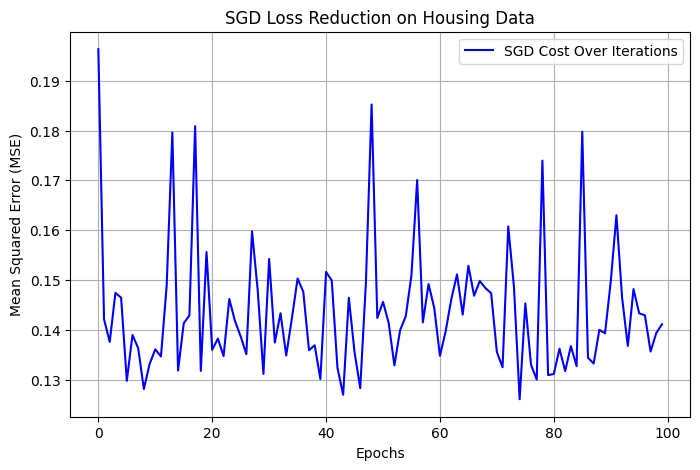

In [12]:
plt.figure(figsize=(8,5))
plt.plot(cost_sgd, label="SGD Cost Over Iterations", color="b")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("SGD Loss Reduction on Housing Data")
plt.legend()
plt.grid()
plt.show()